# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns' , None)

# Data Reading and Understanding

In [2]:
df = pd.read_csv('/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(f'The shape: {df.shape}')

The shape: (891, 12)


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.isna().sum().sort_values(ascending = False) / df.shape[0] * 100

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

In [7]:
df.duplicated().sum()

np.int64(0)

# Data Preprocessing and Feature Engineering

In [8]:
# get the title from the name
df['Title'] = [df['Name'][i].split(',')[1].split('.')[0].strip() for i in range(df.shape[0])]
df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [9]:
# mapping rare titles to more frequent titles
title_mapping = {
    'Mr': 'Mr',
    'Miss': 'Miss',
    'Mrs': 'Mrs',
    'Master': 'Master',
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs',
    'Dr': 'Rare',
    'Rev': 'Rare',
    'Col': 'Rare',
    'Major': 'Rare',
    'Capt': 'Rare',    
    'Don': 'Rare',
    'Lady': 'Rare',
    'Sir': 'Rare',
    'the Countess': 'Rare',
    'Jonkheer': 'Rare'
}

df['Title'] = df['Title'].map(title_mapping)
df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [10]:
# add 2 new important features
df['Family_size'] = df['SibSp'] + df['Parch'] + 1
df['Is_alone'] = (df['Family_size'] == 1).astype(int)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Family_size,Is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1


In [11]:
# drop unnecessary columns
unnec_col = ['PassengerId', 'Name', 'Ticket', 'SibSp', 'Parch']
df.drop(unnec_col, axis = 1, inplace = True)
df.head()

,Survived,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,Family_size,Is_alone
0,0,3,male,22.0,7.2500,NaN,S,Mr,2,0
1,1,1,female,38.0,71.2833,C85,C,Mrs,2,0
2,1,3,female,26.0,7.9250,NaN,S,Miss,1,1
3,1,1,female,35.0,53.1000,C123,S,Mrs,2,0
4,0,3,male,35.0,8.0500,NaN,S,Mr,1,1


In [12]:
# handling null values

# drop 'Cabin' (77.104% of its values is null)
df.drop('Cabin', axis = 1, inplace = True)
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,Family_size,Is_alone
0,0,3,male,22.0,7.2500,S,Mr,2,0
1,1,1,female,38.0,71.2833,C,Mrs,2,0
2,1,3,female,26.0,7.9250,S,Miss,1,1
3,1,1,female,35.0,53.1000,S,Mrs,2,0
4,0,3,male,35.0,8.0500,S,Mr,1,1


In [13]:
# fill null values of 'Age' with the median of the ages in the same 'Title'
df['Age'] = df.groupby('Title')['Age'].transform(lambda x : x.fillna(x.median()))

In [14]:
# fill null values of 'Eparked' with the mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace = True)

In [15]:
df.isna().sum().sort_values(ascending = False) / df.shape[0] * 100

Survived       0.0
Pclass         0.0
Sex            0.0
Age            0.0
Fare           0.0
Embarked       0.0
Title          0.0
Family_size    0.0
Is_alone       0.0
dtype: float64

# Data Visualization

[]

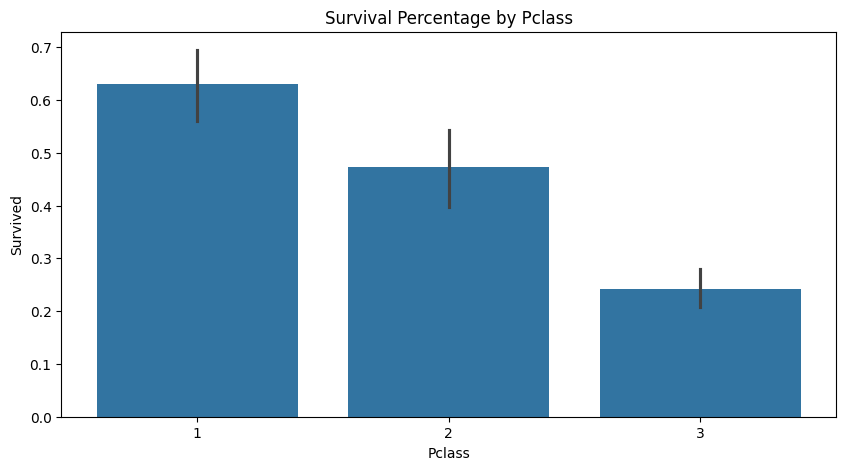

In [16]:
plt.figure(figsize=(10, 5))
sns.barplot(x = df['Pclass'], y = df['Survived'])
plt.title('Survival Percentage by Pclass')
plt.plot()
# most survived people was from Pclass 1

[]

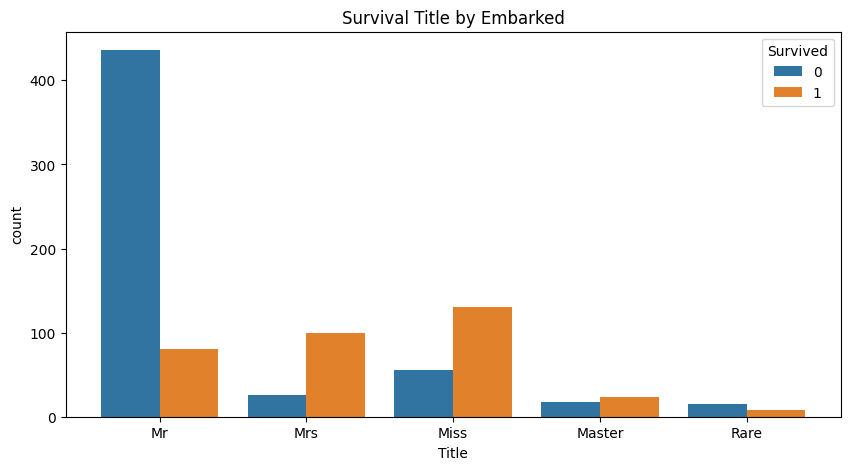

In [17]:
plt.figure(figsize=(10, 5))
sns.countplot(x = df['Title'], hue = df['Survived'])
plt.title('Survival Title by Embarked')
plt.plot()

[]

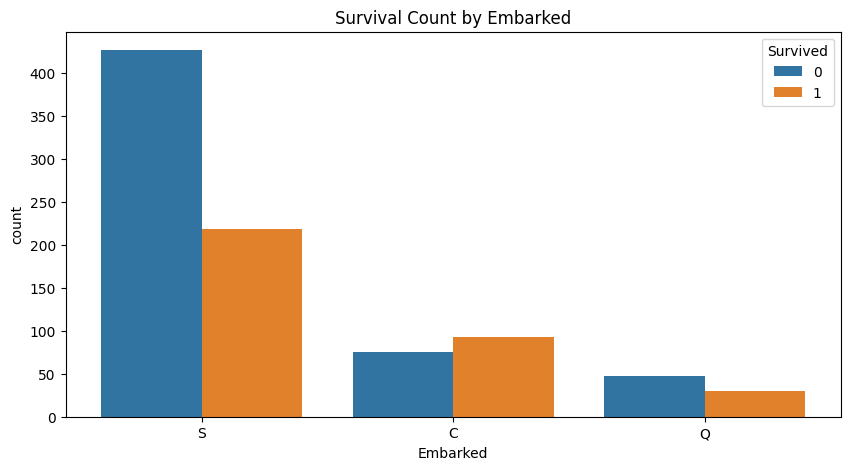

In [18]:
plt.figure(figsize=(10, 5))
sns.countplot(x = df['Embarked'], hue = df['Survived'])
plt.title('Survival Count by Embarked')
plt.plot()

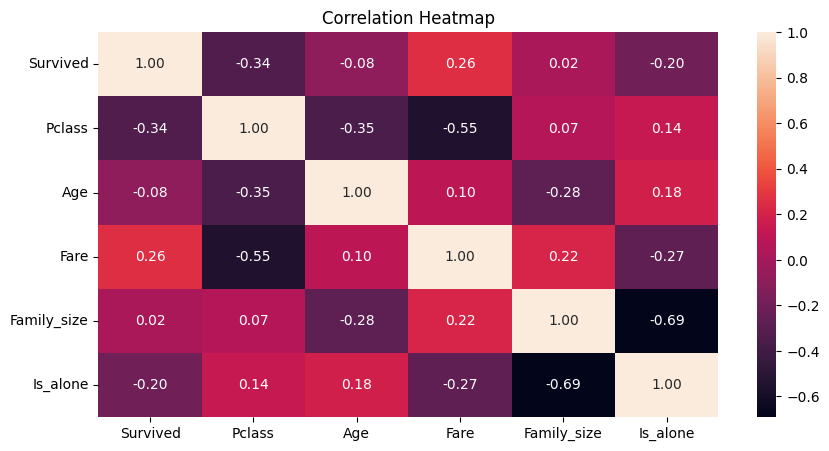

In [19]:
num_col = df.select_dtypes(include = [np.number]).columns
plt.figure(figsize = (10, 5))
sns.heatmap(df[num_col].corr(), annot = True, fmt = '.2f')
plt.title('Correlation Heatmap')
plt.show()

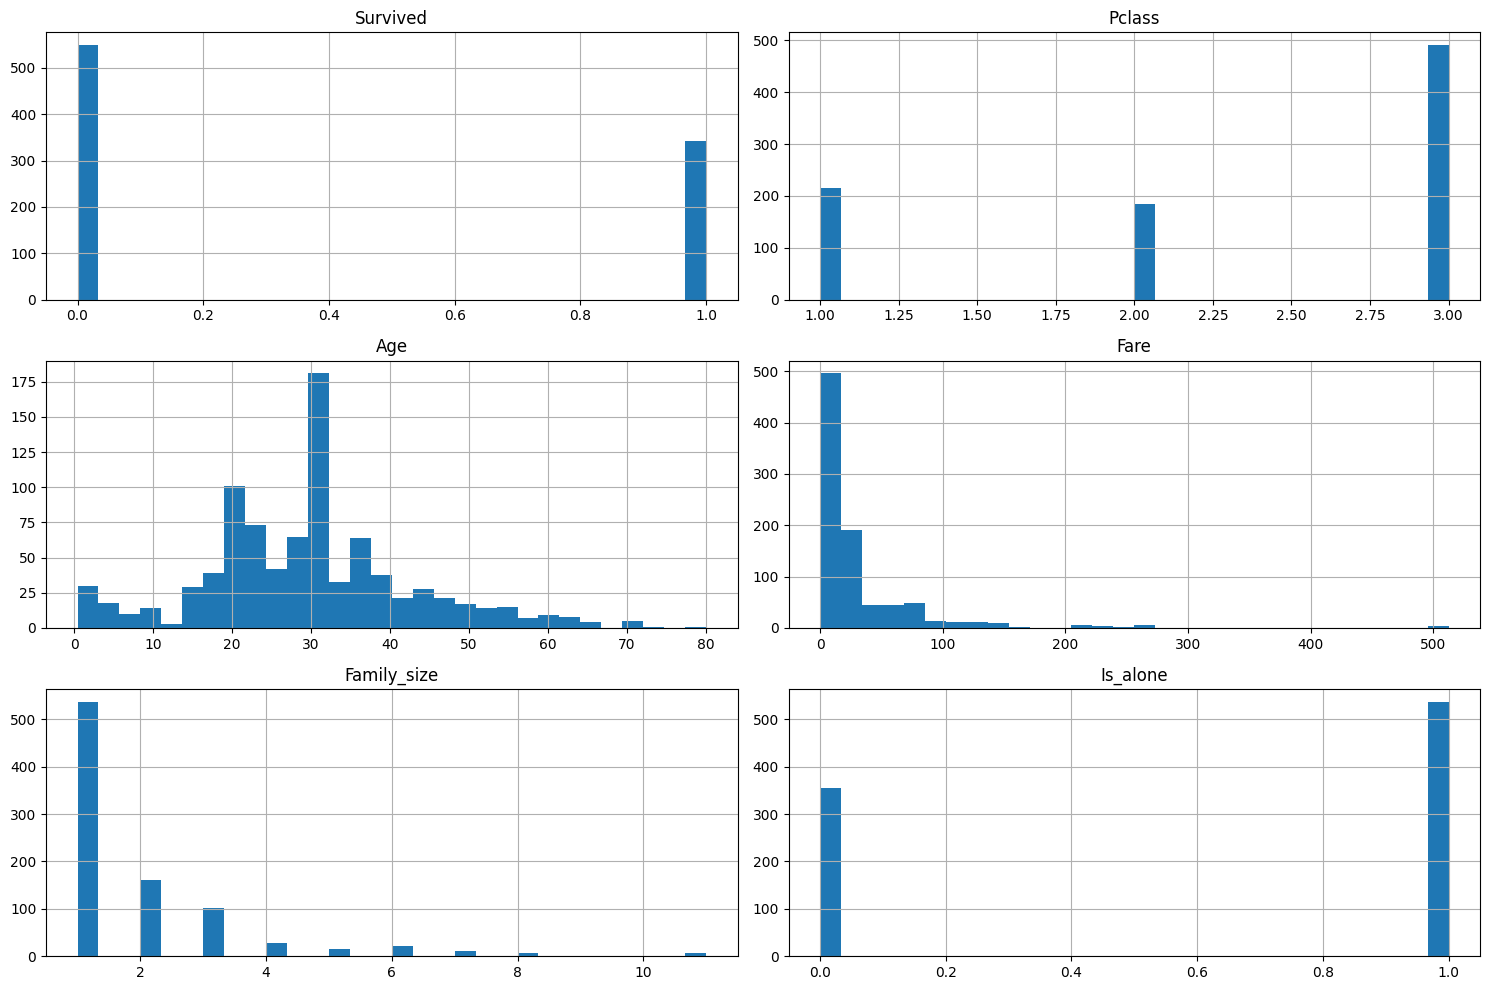

In [20]:
df.hist(figsize=(15, 10), bins = 30)
plt.tight_layout()
plt.show()

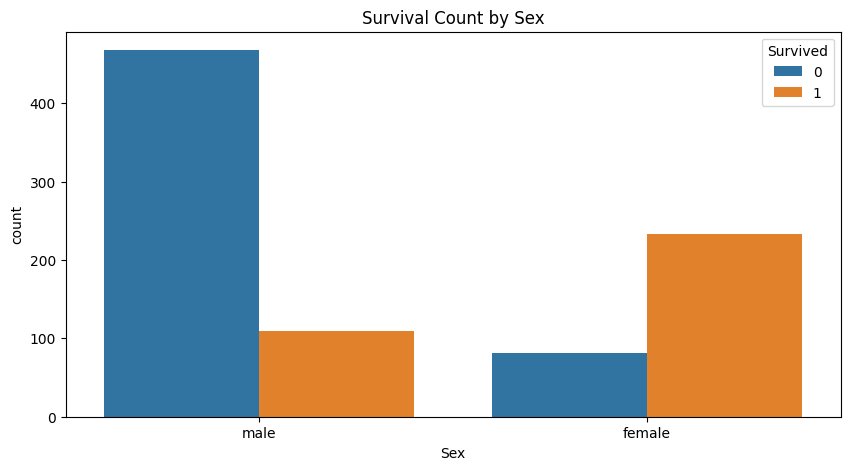

In [21]:
plt.figure(figsize=(10, 5))
sns.countplot(x = df['Sex'], hue = df['Survived'])
plt.title('Survival Count by Sex')
plt.show()

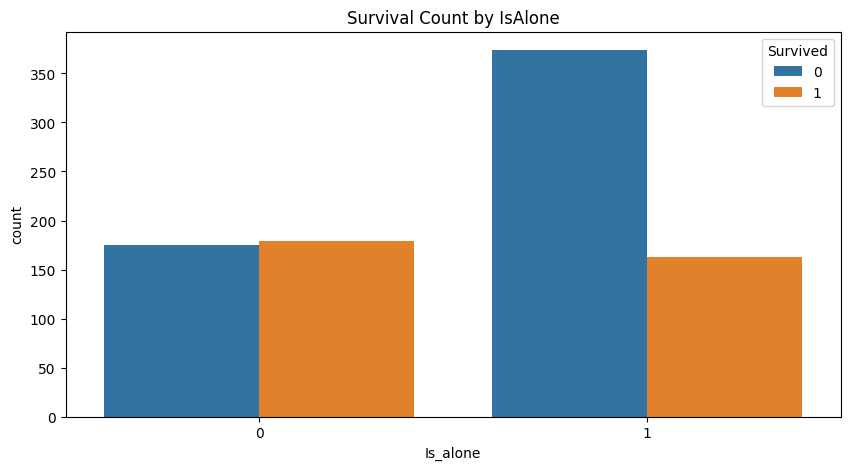

In [22]:
plt.figure(figsize=(10, 5))
sns.countplot(x = df['Is_alone'], hue = df['Survived'])
plt.title('Survival Count by IsAlone')
plt.show()

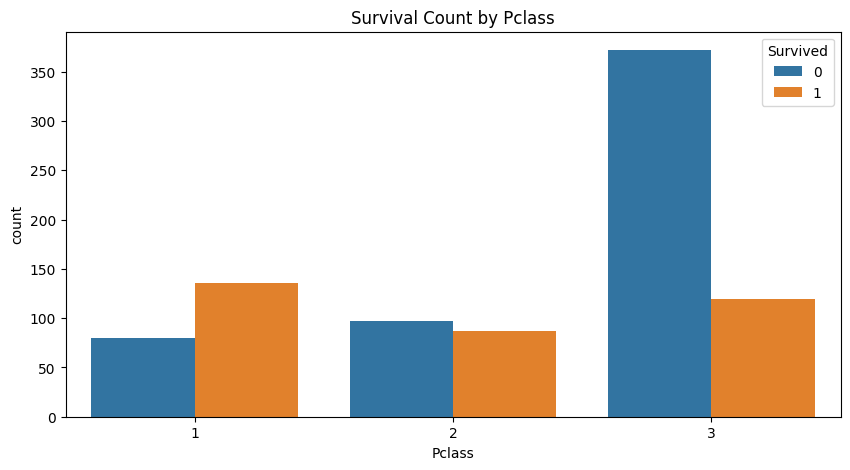

In [23]:
plt.figure(figsize=(10, 5))
sns.countplot(x = df['Pclass'], hue = df['Survived'])
plt.title('Survival Count by Pclass')
plt.show()

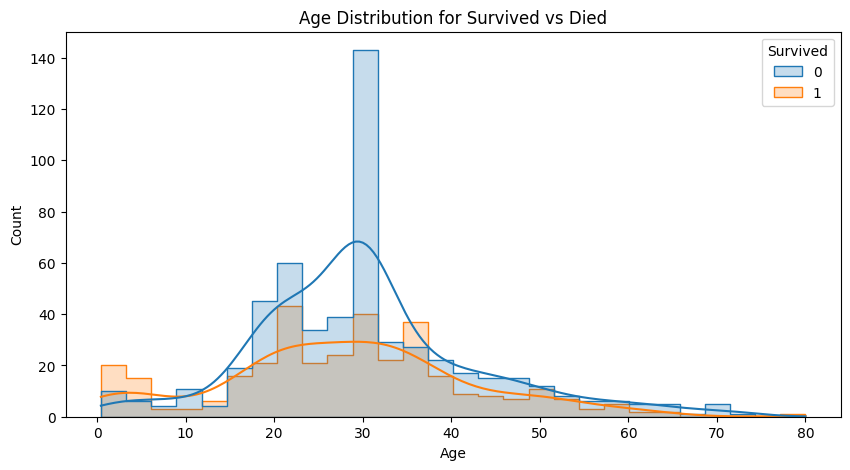

In [24]:
plt.figure(figsize=(10, 5))
sns.histplot(x = df['Age'], hue = df['Survived'], kde = True, element='step')
plt.title('Age Distribution for Survived vs Died')
plt.show()

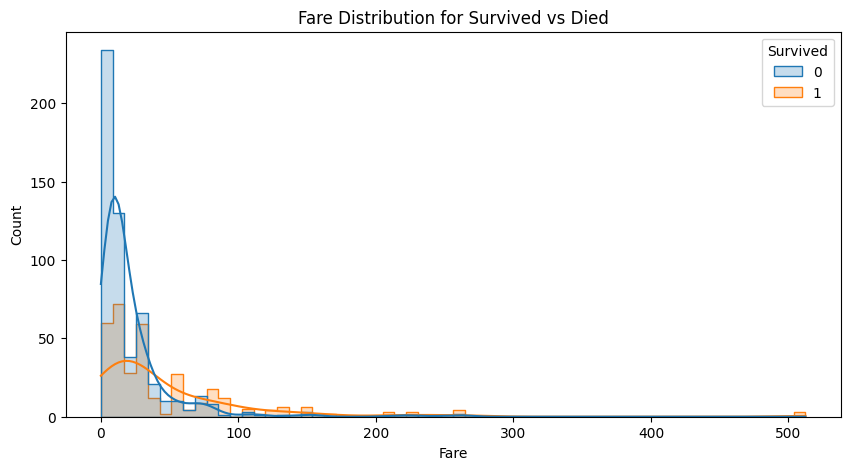

In [25]:
plt.figure(figsize=(10, 5))
sns.histplot(x = df['Fare'], hue = df['Survived'], kde = True, element='step')
plt.title('Fare Distribution for Survived vs Died')
plt.show()

# Modeling

In [26]:
X = df.drop('Survived', axis = 1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [27]:
num_col = ['Age', 'Fare', 'Family_size']
num_col

['Age', 'Fare', 'Family_size']

In [28]:
cat_col = ['Sex', 'Pclass', 'Embarked', 'Title', 'Is_alone']
cat_col

['Sex', 'Pclass', 'Embarked', 'Title', 'Is_alone']

## Logistic Regression

In [29]:
preprocessor_lr = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(drop = 'first'), cat_col),
        ('num', StandardScaler(), num_col)
    ]
)

In [30]:
model_lr = LogisticRegression(max_iter = 1000)

In [31]:
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor_lr),
    ('model', model_lr)
])

In [32]:
pipeline_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Sex', 'Pclass', 'Embarked',
                                                   'Title', 'Is_alone']),
                                                 ('num', StandardScaler(),
                                                  ['Age', 'Fare',
                                                   'Family_size'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [33]:
y_pred_lr = pipeline_lr.predict(X_test)

In [34]:
print(f'Accuracy = {accuracy_score(y_test, y_pred_lr) * 100 : .2f}')

Accuracy =  82.68


In [35]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



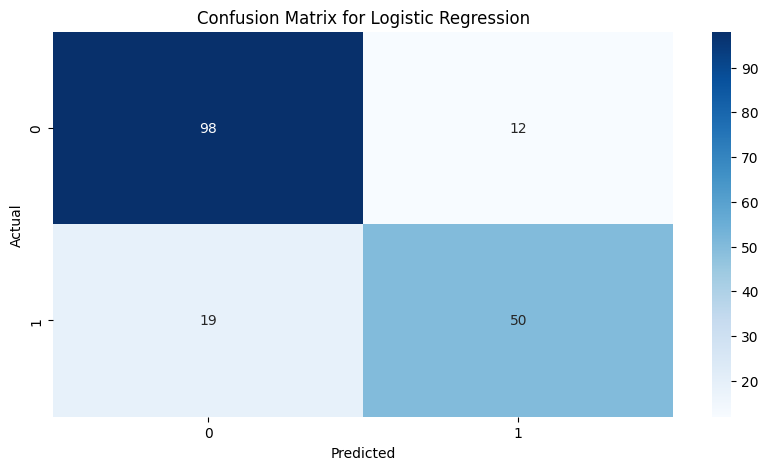

In [36]:
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize = (10, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [37]:
y_pred_prob = pipeline_lr.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

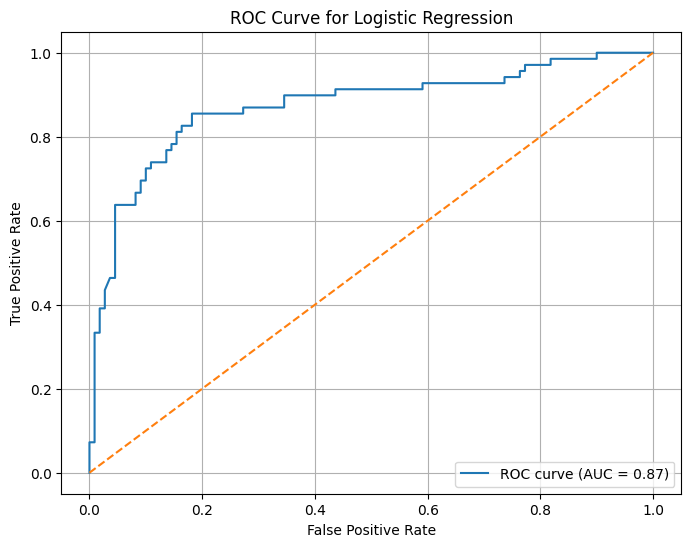

In [38]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Random Forest

In [39]:
# no need for standardization
preprocessor_rf = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(drop = 'first'), cat_col),
    ]
)

In [40]:
model_rf = RandomForestClassifier()

In [41]:
pipeline_rf = Pipeline(steps=[
        ('preprocessor', preprocessor_rf),
        ('model', model_rf)
    ]
)

In [42]:
params_rf = {
    'model__n_estimators': [100, 150, 200],
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(pipeline_rf, params_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

print(f'Best Params: {grid_rf.best_params_}')
print(f'Best Score: {grid_rf.best_score_:.2f}')

Best Params: {'model__max_depth': None, 'model__min_samples_split': 10, 'model__n_estimators': 100}
Best Score: 0.83


In [43]:
y_pred_rf = grid_rf.predict(X_test)

In [44]:
print(f'Accuracy = {accuracy_score(y_test, y_pred_rf) * 100 : .2f}')

Accuracy =  79.89


In [45]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.78      0.94      0.85       110
           1       0.85      0.58      0.69        69

    accuracy                           0.80       179
   macro avg       0.82      0.76      0.77       179
weighted avg       0.81      0.80      0.79       179



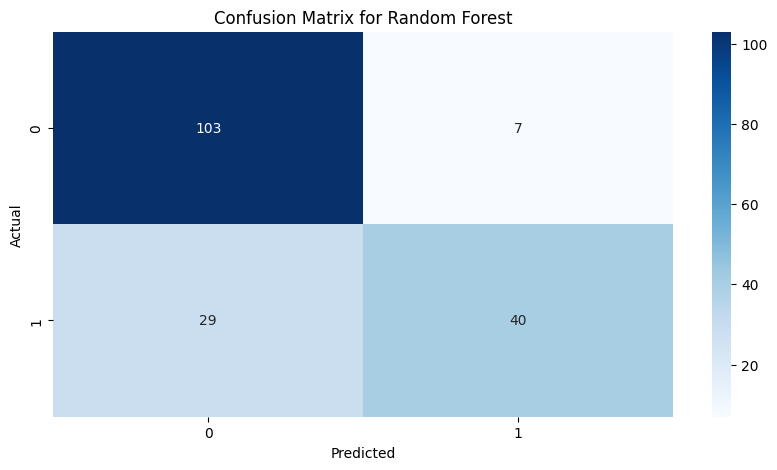

In [46]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize = (10, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest')
plt.show()

In [47]:
y_pred_prob = grid_rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

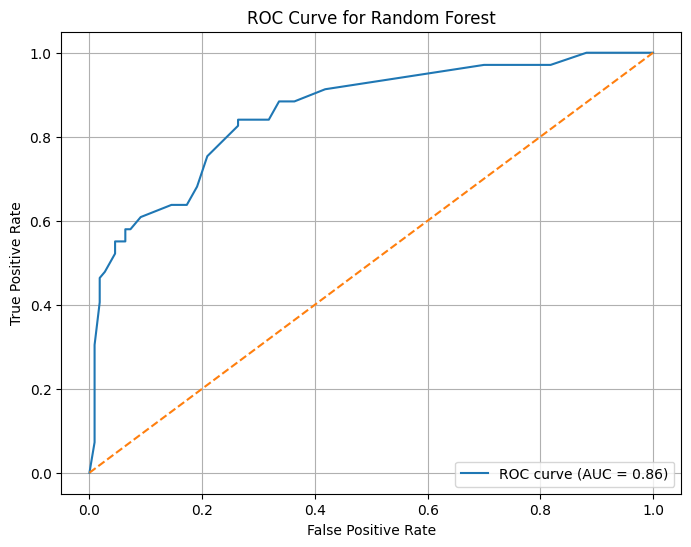

In [48]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## XGBoost

In [49]:
# no need for standardization
preprocessor_xgb = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(drop = 'first'), cat_col),
    ]
)

In [50]:
model_xgb = XGBClassifier()

In [51]:
pipeline_xgb = Pipeline(steps=[
        ('preprocessor', preprocessor_xgb),
        ('model', model_xgb)
    ]
)

In [52]:
params_xgb = {
    'model__n_estimators': [100, 150, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.3]
}

grid_xgb = GridSearchCV(pipeline_xgb, params_xgb, cv=5, scoring='accuracy')
grid_xgb.fit(X_train, y_train)

print(f'Best Params: {grid_xgb.best_params_}')
print(f'Best Score: {grid_xgb.best_score_:.2f}')

Best Params: {'model__learning_rate': 0.3, 'model__max_depth': 3, 'model__n_estimators': 150}
Best Score: 0.83


In [53]:
y_pred_xgb = grid_xgb.predict(X_test)

In [54]:
print(f'Accuracy = {accuracy_score(y_test, y_pred_xgb) * 100 : .2f}')

Accuracy =  79.89


In [55]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.78      0.94      0.85       110
           1       0.85      0.58      0.69        69

    accuracy                           0.80       179
   macro avg       0.82      0.76      0.77       179
weighted avg       0.81      0.80      0.79       179



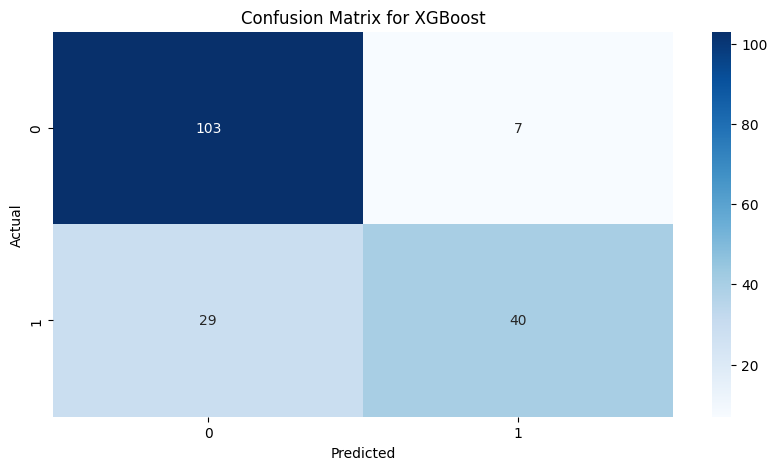

In [56]:
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize = (10, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for XGBoost')
plt.show()

In [57]:
y_pred_prob = grid_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

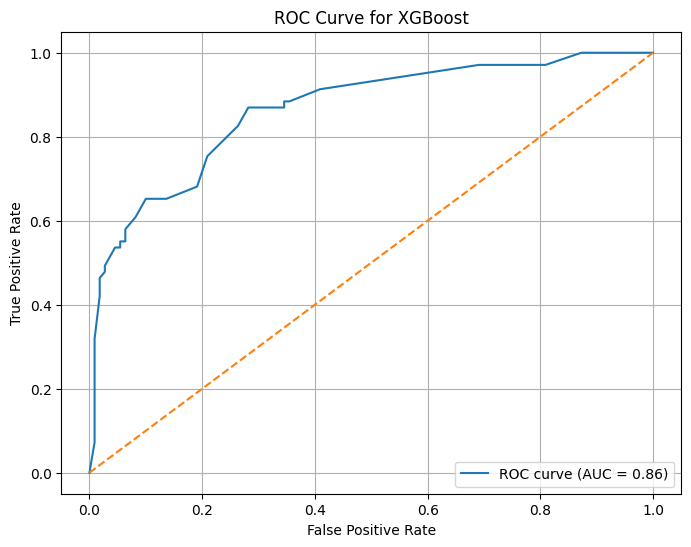

In [58]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Comparison

In [59]:
results = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'ROC AUC': roc_auc_score(y_test, pipeline_lr.predict_proba(X_test)[:, 1]),
        'Prob': pipeline_lr.predict_proba(X_test)[:, 1]
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'ROC AUC': roc_auc_score(y_test, grid_rf.predict_proba(X_test)[:, 1]),
        'Prob': grid_rf.predict_proba(X_test)[:, 1]
    },
    'XGBoost': {
        'Accuracy': accuracy_score(y_test, y_pred_xgb),
        'ROC AUC': roc_auc_score(y_test, grid_xgb.predict_proba(X_test)[:, 1]),
        'Prob': grid_xgb.predict_proba(X_test)[:, 1]
    }
}

results_df = pd.DataFrame(results).T.reset_index()
results_df.rename(columns={'index' : 'Model'}, inplace = True)
results_df.drop('Prob', axis = 1, inplace = True)
results_df

,Model,Accuracy,ROC AUC
0,Logistic Regression,0.826816,0.8722
1,Random Forest,0.798883,0.8583
2,XGBoost,0.798883,0.863702


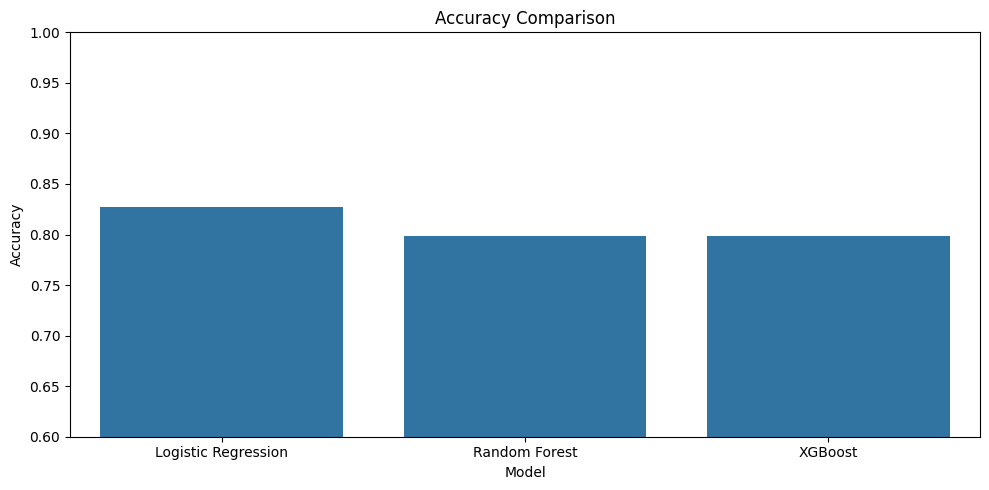

In [60]:
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df['Model'], y=results_df['Accuracy'])
plt.title('Accuracy Comparison')
plt.ylim(0.6, 1.0)
plt.tight_layout()
plt.show()

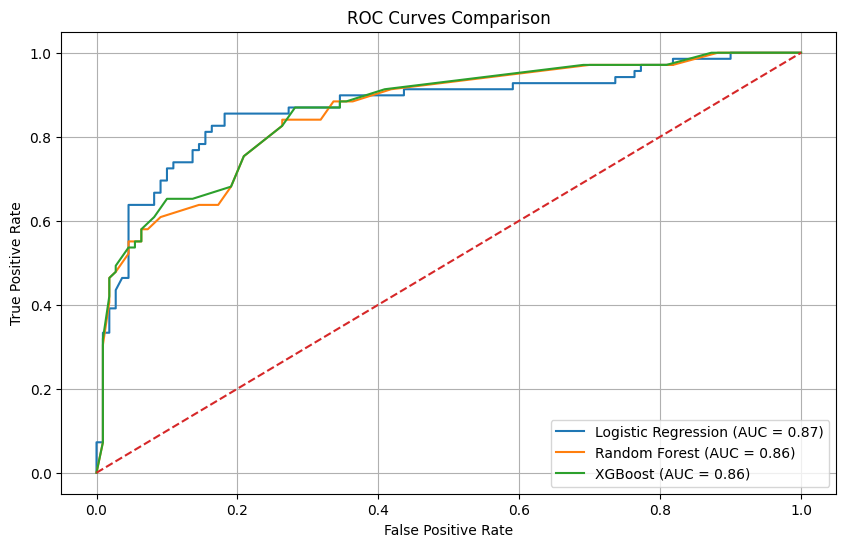

In [61]:
plt.figure(figsize=(10, 6))

for model in results:
    fpr, tpr, _ = roc_curve(y_test, results[model]['Prob'])
    auc = results[model]['ROC AUC']
    plt.plot(fpr, tpr, label=f'{model} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True)
plt.show()